In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assignment 1: Groupby

Can you return a table containing the top 10 stores by total transactions in the data?

Make sure they’re sorted from highest to lowest.

Thanks!

In [2]:
# Read in transactions data -- parse dates specified here for help with later problem

transactions = pd.read_csv("files/transactions.csv", parse_dates=["date"])

transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [3]:
top10_stores = (
    transactions.groupby("store_nbr")["transactions"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="total_transactions")
)

top10_stores


,store_nbr,total_transactions
0,44,7273093
1,47,6535810
2,45,6201115
3,46,5990113
4,3,5366350
5,48,5107785
6,8,4637971
7,49,4574103
8,50,4384444
9,11,3972488


# Assignment 2: Groupby Multiple Columns

Can you get me the total transactions by store and month? 

Sort the table from first month to last, then by highest transactions to lowest within each month. 


In [4]:
# helper code to extract month date part from date column

transactions["month"] = transactions["date"].dt.month

transactions.head()

,date,store_nbr,transactions,month
0,2013-01-01,25,770,1
1,2013-01-02,1,2111,1
2,2013-01-02,2,2358,1
3,2013-01-02,3,3487,1
4,2013-01-02,4,1922,1


In [5]:
store_month_totals = (
    transactions.groupby(["month", "store_nbr"], as_index=False)["transactions"]
    .sum()
    .rename(columns={"transactions": "total_transactions"})
    .sort_values(by=["month", "total_transactions"], ascending=[True, False])
)

store_month_totals


,month,store_nbr,total_transactions
43,1,44,628438
46,1,47,568824
44,1,45,538370
45,1,46,522763
2,1,3,463260
...,...,...,...
619,12,32,86167
608,12,21,84128
629,12,42,76741
616,12,29,76627


# Assignment 3: Multi-Index DataFrames


Can you help me access rows and columns with multiple indices? I’ve been struggling with multi-index DataFrames.

Access:
* Grab Store 3, Month 1
* Then, select the column storing the mean of transactions

Fix:
* Drop the outer layer of the column Index
* Reset the row index so it is the default integer index

In [6]:
# Ross' grouped DataFrame code, run this first

grouped = (
    transactions.groupby(["store_nbr", "month"])
    .agg({"transactions": ["sum", "mean"]})
    .sort_values(by=["month", ("transactions", "sum")], ascending=[True, False])
)

In [7]:
# df grouped by store and month with two aggregation columns

grouped.head()

transactions             
                         sum         mean
store_nbr month                          
44        1           628438  4246.202703
47        1           568824  3843.405405
45        1           538370  3637.635135
46        1           522763  3532.182432
3         1           463260  3151.428571

In [8]:
store3_month1_mean = grouped.loc[(3, 1), ("transactions", "mean")]
store3_month1_mean


np.float64(3151.4285714285716)

In [9]:
grouped_fixed = grouped.copy()
grouped_fixed.columns = grouped_fixed.columns.droplevel(0)  # paliks: sum, mean
grouped_fixed.head()


,,sum,mean
store_nbr,month,,
44,1,628438,4246.202703
47,1,568824,3843.405405
45,1,538370,3637.635135
46,1,522763,3532.182432
3,1,463260,3151.428571


In [10]:
grouped_fixed = grouped_fixed.reset_index()
grouped_fixed.head()


,store_nbr,month,sum,mean
0,44,1,628438,4246.202703
1,47,1,568824,3843.405405
2,45,1,538370,3637.635135
3,46,1,522763,3532.182432
4,3,1,463260,3151.428571


# Assignment 4: The Agg Method

Calculate the mean of target met by store, and the sum of bonuses to be paid to each store.

Sort them by highest to lowest bonus payout.

Then, do the same for day of week and month.

In [11]:
# Recreate table from section 3

transactions = transactions.assign(
    target_pct=transactions["transactions"] / 2500,
    met_target=(transactions["transactions"] / 2500) >= 1,
    bonus_payable=((transactions["transactions"] / 2500) >= 1) * 100,
    month=transactions.date.dt.month,
    day_of_week=transactions.date.dt.dayofweek,
)

transactions.head()

,date,store_nbr,transactions,month,target_pct,met_target,bonus_payable,day_of_week
0,2013-01-01,25,770,1,0.3080,False,0,1
1,2013-01-02,1,2111,1,0.8444,False,0,2
2,2013-01-02,2,2358,1,0.9432,False,0,2
3,2013-01-02,3,3487,1,1.3948,True,100,2
4,2013-01-02,4,1922,1,0.7688,False,0,2


In [12]:
store_perf = (
    transactions.groupby("store_nbr")
    .agg(met_target_mean=("met_target", "mean"),
         bonus_total=("bonus_payable", "sum"))
    .sort_values("bonus_total", ascending=False)
)

store_perf


,met_target_mean,bonus_total
store_nbr,,
47,0.999404,167600
44,0.998807,167500
3,0.998210,167300
45,0.997615,167300
46,0.989267,165900
8,0.888425,148900
48,0.690519,115800
49,0.637448,106900
50,0.453190,76000


In [13]:
dow_perf = (
    transactions.groupby("day_of_week")
    .agg(met_target_mean=("met_target", "mean"),
         bonus_total=("bonus_payable", "sum"))
    .sort_values("bonus_total", ascending=False)
)

dow_perf


,met_target_mean,bonus_total
day_of_week,,
5,0.222204,266400
6,0.204001,241700
4,0.179007,213000
0,0.160214,191600
2,0.160572,191000
1,0.146299,175500
3,0.142077,169100


In [14]:
month_perf = (
    transactions.groupby("month")
    .agg(met_target_mean=("met_target", "mean"),
         bonus_total=("bonus_payable", "sum"))
    .sort_values("bonus_total", ascending=False)
)

month_perf


,met_target_mean,bonus_total
month,,
12,0.255640,154100
5,0.170792,131800
3,0.169461,130400
4,0.174469,129700
7,0.162486,126300
2,0.174230,121700
6,0.161706,121700
8,0.174189,120800
1,0.163723,119600


# Assignment 4: Transform

Calculate the mean of transactions by store number and day of week while keeping row numbers. 

Then compare the performance of each row to its day of week average. (difference between transactions and daily avg)

In [15]:
transactions = transactions.copy()

transactions["dow_avg"] = transactions.groupby(["store_nbr", "day_of_week"])["transactions"].transform("mean")
transactions["diff_from_dow_avg"] = transactions["transactions"] - transactions["dow_avg"]

transactions[["date", "store_nbr", "day_of_week", "transactions", "dow_avg", "diff_from_dow_avg"]].head()


,date,store_nbr,day_of_week,transactions,dow_avg,diff_from_dow_avg
0,2013-01-01,25,1,770,740.245690,29.754310
1,2013-01-02,1,2,2111,1870.782427,240.217573
2,2013-01-02,2,2,2358,1952.652720,405.347280
3,2013-01-02,3,2,3487,3142.682008,344.317992
4,2013-01-02,4,2,1922,1499.569038,422.430962


# Assignment 5: Pivot

Pivot transactions with store number as index, columns day of week, with the sum of bonus payable as cells.

Filter to stores that had a non-zero bonus payable and create a heatmap.

Then unpivot (melt) the table so we have one row for each store and day of the week with the corresponding total owed. 


In [16]:
# Use transactions table (ok if includes columns from assignment 4 or not)

transactions.head()

,date,store_nbr,transactions,month,target_pct,met_target,bonus_payable,day_of_week,dow_avg,diff_from_dow_avg
0,2013-01-01,25,770,1,0.3080,False,0,1,740.245690,29.754310
1,2013-01-02,1,2111,1,0.8444,False,0,2,1870.782427,240.217573
2,2013-01-02,2,2358,1,0.9432,False,0,2,1952.652720,405.347280
3,2013-01-02,3,3487,1,1.3948,True,100,2,3142.682008,344.317992
4,2013-01-02,4,1922,1,0.7688,False,0,2,1499.569038,422.430962


In [17]:
pivot_bonus = transactions.pivot_table(
    index="store_nbr",
    columns="day_of_week",
    values="bonus_payable",
    aggfunc="sum",
    fill_value=0
)

pivot_bonus.head()


day_of_week,0,1,2,3,4,5,6
store_nbr,,,,,,,
1,200,300,300,200,100,0,0
2,300,600,500,400,400,500,200
3,24000,23900,23900,23900,23900,24000,23700
4,200,300,300,200,100,200,0
5,200,300,300,100,100,100,0


In [18]:
pivot_bonus_nonzero = pivot_bonus.loc[pivot_bonus.sum(axis=1) > 0]
pivot_bonus_nonzero


day_of_week,0,1,2,3,4,5,6
store_nbr,,,,,,,
1,200,300,300,200,100,0,0
2,300,600,500,400,400,500,200
3,24000,23900,23900,23900,23900,24000,23700
4,200,300,300,200,100,200,0
5,200,300,300,100,100,100,0
6,400,500,500,300,200,900,300
7,200,300,300,200,100,100,0
8,22000,18800,23800,18000,22900,23400,20000
9,1200,800,800,700,400,7900,5100


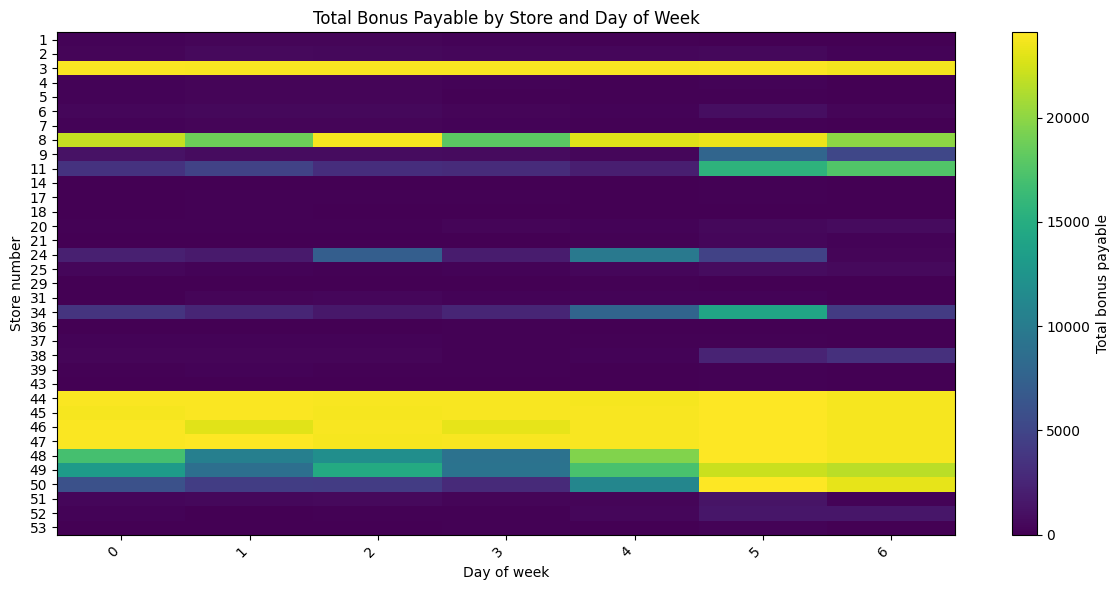

In [19]:
import matplotlib.pyplot as plt
import numpy as np

data = pivot_bonus_nonzero.to_numpy()

plt.figure(figsize=(12, 6))
plt.imshow(data, aspect="auto")
plt.colorbar(label="Total bonus payable")

plt.xticks(
    ticks=np.arange(pivot_bonus_nonzero.shape[1]),
    labels=pivot_bonus_nonzero.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(pivot_bonus_nonzero.shape[0]),
    labels=pivot_bonus_nonzero.index
)

plt.title("Total Bonus Payable by Store and Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Store number")
plt.tight_layout()
plt.show()


In [20]:
melted_bonus = (
    pivot_bonus_nonzero.reset_index()
    .melt(id_vars="store_nbr", var_name="day_of_week", value_name="total_bonus_payable")
)

melted_bonus.head()


,store_nbr,day_of_week,total_bonus_payable
0,1,0,200
1,2,0,300
2,3,0,24000
3,4,0,200
4,5,0,200
